In [206]:
import pandas as pd
import numpy as np

In [207]:
df = pd.read_csv('players_data-2025_2026.csv')

df.head()
df = df[df['Pos'] != 'GK']
df['Pos'].value_counts()

Pos
MF       922
DF       705
FW       398
MF,FW    217
FW,MF    144
DF,MF    141
MF,DF    115
DF,FW      3
Name: count, dtype: int64

Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)
Creen un Jupyter Notebook nuevo, carguen el dataset proporcionado en GitHub y seleccionen a su "Jugador Estrella" (puede ser el jugador con más goles o su favorito del dataset, la decisión es suya).

1. Construyan la matriz multidimensional X seleccionando al menos 4 características numéricas (pueden ser más) continuas (float) que definan el rendimiento del jugador (por ejemplo: Goles, Asistencias, Minutos_Jugados, Precisión_Pases, Recuperaciones, etc.).
2. Creen un vector para su jugador estrella y otro vector para el resto de los candidatos.

In [208]:
metrics = ['Min', 'Gls', 'Ast', 'Sh/90', 'SoT%','Int']

new_df = df[['Player']+metrics]
star = new_df.loc[new_df['Player'] == "Erling Haaland"]
print(star)
players = new_df[new_df['Player'] != "Erling Haaland"]

players = players.drop(columns='Player')
star = star.drop(columns='Player')

players.isna().sum()
players['SoT%'] = players['SoT%'].fillna(0)
players.isna().sum()

              Player   Min  Gls  Ast  Sh/90  SoT%  Int
1104  Erling Haaland  2953   27    8   3.84  46.8    4


Min      0
Gls      0
Ast      0
Sh/90    0
SoT%     0
Int      0
dtype: int64

3. Pregunta de control: Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)? Apliquen esa transformación en el código.

In [209]:
players_scaled = (players - players.mean()) / players.std()
star_scaled = (star - players.mean()) / players.std()

Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)
La distancia euclidiana (la línea recta) no es la única forma de viajar por el espacio vectorial. Existen otras métricas como la Distancia Manhattan (Norma L1), que calcula la distancia moviéndose estrictamente en ángulos rectos, como si un taxi navegara por las cuadras de Nueva York, también es conocida como la distancia del taxista.

Misión:

1. Investiguen y escriban en su Notebook la fórmula matemática de la Distancia Manhattan.
2. Programen una celda para encontrar al jugador más similar a su estrella usando la Distancia Euclidiana. Impriman el nombre del reemplazo sugerido.
3. En la siguiente celda, busquen al reemplazo calculando la Distancia Manhattan (deberán generar una función custom para calcular esta distancia).
4. Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.


1. Investiguen y escriban en su Notebook la fórmula matemática de la Distancia Manhattan.

Distancia = |x1 - x2| + |y1 - y2|

2. Programen una celda para encontrar al jugador más similar a su estrella usando la Distancia Euclidiana. Impriman el nombre del reemplazo sugerido.

In [210]:
players['euclidian'] = np.linalg.norm(players_scaled.values - star_scaled.values, ord=2, axis=1)
closest_eu = df.loc[players['euclidian'].idxmin()]
print(players['euclidian'].min())
print(closest_eu[['Player'] + metrics])

1.8576918429281015
Player    Kylian Mbappé
Min                2599
Gls                  25
Ast                   5
Sh/90              5.06
SoT%               43.2
Int                   3
Name: 1701, dtype: object


3. En la siguiente celda, busquen al reemplazo calculando la Distancia Manhattan (deberán generar una función custom para calcular esta distancia).

In [211]:
players['manhattan'] = np.linalg.norm(players_scaled.values - star_scaled.values, ord=1, axis=1)
closest_mh = df.loc[players['manhattan'].idxmin()]
print(players['manhattan'].min())
print(closest_mh[['Player'] + metrics])


3.4068391572136223
Player    Kylian Mbappé
Min                2599
Gls                  25
Ast                   5
Sh/90              5.06
SoT%               43.2
Int                   3
Name: 1701, dtype: object


4. Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.



**R** = Mbappé fue el jugador mas cercano para ambos distancias. si nos imaginamos que el spacio entre ambos puntos es un tipo triángulo, Manhattan calcula la suma de los catetos mientras que Euclidiana se basa en la hipotenusa, lo que resulta en que las distancias de Manhattan son mayores.

Fase 3: El Reto de Visualización en 4D (Investigación Independiente)
El director técnico quiere ver un reporte visual de por qué el jugador que sugirieron es el más parecido al original.

El problema físico es que ustedes seleccionaron 4 (o más) características. Los seres humanos solo podemos ver un eje X, un eje Y y un eje Z.

Misión de Investigación:

Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.(Pistas que pueden investigar: Gráficos de Radar / Spider Charts, Coordenadas Paralelas, o el uso de color/tamaño como cuartas dimensiones en un Scatter 3D).
Implementen el código para visualizar a su "Jugador Estrella" junto al "Reemplazo Sugerido" y a un "Tercer Jugador Aleatorio" (para ver el contraste).
Entreguen el Notebook documentado comprobando visualmente que los vectores de su estrella y su clon están, efectivamente, muy cerca en el hiperespacio.


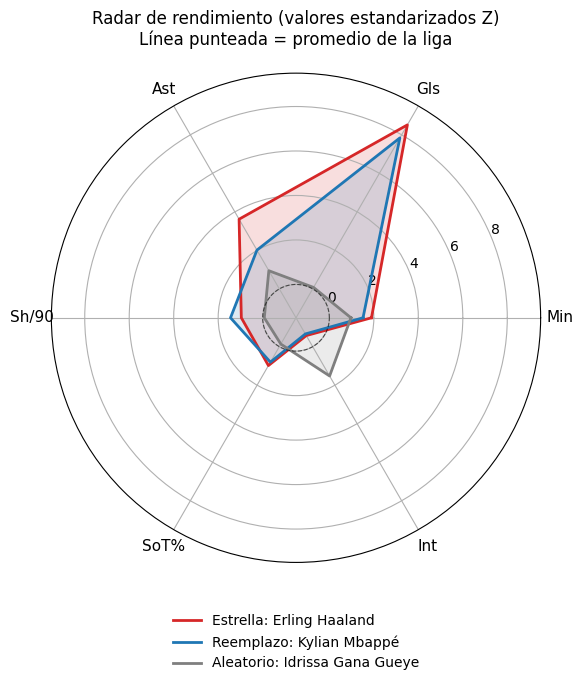

Distancia euclidiana a Erling Haaland:
  Kylian Mbappé: 1.858
  Idrissa Gana Gueye: 9.269


In [212]:
import matplotlib.pyplot as plt

idx_clon = players['euclidian'].idxmin()
idx_random = players_scaled.drop(index=idx_clon).sample(1, random_state=42).index[0]

star_vec = star_scaled.values[0]
clon_vec = players_scaled.loc[idx_clon].values
random_vec = players_scaled.loc[idx_random].values

nombre_star = "Erling Haaland"
nombre_clon = df.loc[idx_clon, 'Player']
nombre_random = df.loc[idx_random, 'Player']

angulos = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angulos += angulos[:1]

def cerrar(v):
    v = list(v)
    return v + v[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

jugadores = [
    (star_vec, f'Estrella: {nombre_star}', '#d62728'),
    (clon_vec, f'Reemplazo: {nombre_clon}', '#1f77b4'),
    (random_vec, f'Aleatorio: {nombre_random}', '#7f7f7f'),
]
for vec, etiqueta, color in jugadores:
    ax.plot(angulos, cerrar(vec), color=color, linewidth=2, label=etiqueta)
    ax.fill(angulos, cerrar(vec), color=color, alpha=0.15)

todos = np.concatenate([star_vec, clon_vec, random_vec])
ax.set_ylim(np.floor(todos.min()) - 0.5, np.ceil(todos.max()) + 0.5)

ax.plot(np.linspace(0, 2 * np.pi, 200), [0] * 200, 'k--', linewidth=0.8, alpha=0.6)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_title('Radar de rendimiento (valores estandarizados Z)\nLínea punteada = promedio de la liga', pad=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.tight_layout()
plt.show()

print(f"Distancia euclidiana a {nombre_star}:")
print(f"  {nombre_clon}: {players.loc[idx_clon, 'euclidian']:.3f}")
print(f"  {nombre_random}: {players.loc[idx_random, 'euclidian']:.3f}")